In [3]:
# Load + standardize index
import pandas as pd
import numpy as np
from pathlib import Path

REGION = "norcal"  # norcal / midcal / socal
PATH = Path(f"../../1_DATA/processed/{REGION}/{REGION}_kelp_sst_ui_labeled.csv")

df = pd.read_csv(PATH, index_col=0, parse_dates=True).sort_index()
df.index = pd.to_datetime(df.index).tz_localize(None)
df.index = df.index.to_period("Q").to_timestamp(how="start")

print(REGION, "rows:", len(df), "range:", df.index.min(), "to", df.index.max())
df.head()

norcal rows: 152 range: 1984-04-01 00:00:00 to 2025-07-01 00:00:00


,kelp_area,kelp_smooth,coverage,coverage_frac,kelp_q_z,kelp_z_1yr,collapse,suppressed,sstanom_q_mean,sstanom_q_max,sstanom_q_mean_lag1,ui_q_mean,ui_q_min,uianom_q_mean,uianom_q_min,uianom_q_mean_lag1,ui_q_mean_lag1
1984-04-01,13657.0,9363.00,28671,0.969171,-1.409001,NaN,1,0,-0.046608,0.577767,0.531792,197.333333,111.0,77.333333,32.0,4.666667,15.333333
1984-10-01,92444.0,28080.50,29336,0.991651,-1.398554,NaN,1,0,-0.276030,-0.128920,0.221706,2.333333,-32.0,2.000000,-25.0,85.333333,213.333333
1985-04-01,85658.0,127546.50,28779,0.972822,-1.027905,NaN,0,0,-0.627068,-0.006830,-0.890579,137.666667,107.0,17.666667,-4.0,32.666667,43.333333
1985-10-01,1834162.0,563355.75,28117,0.950445,0.473695,-0.840441,0,0,-0.961948,-0.541627,-0.004669,26.666667,-11.0,26.333333,1.0,-7.666667,120.333333
1986-01-01,2671.0,550291.25,29131,0.984721,0.372646,-0.395030,0,0,0.745422,1.148107,-0.961948,-52.666667,-124.0,-63.333333,-111.0,26.333333,26.666667


In [4]:
# Define helper: block bootstrap CI for mean diff + AUC
from sklearn.metrics import roc_auc_score

def block_bootstrap_mean_diff_auc(score, y, block_len=4, B=3000, seed=0):
    score = np.asarray(score)
    y = np.asarray(y).astype(int)
    n = len(y)

    starts = np.arange(0, n - block_len + 1)
    n_blocks = int(np.ceil(n / block_len))
    rng = np.random.default_rng(seed)

    diffs, aucs = [], []
    for _ in range(B):
        chosen = rng.choice(starts, size=n_blocks, replace=True)
        idx = np.concatenate([np.arange(s, s + block_len) for s in chosen])[:n]

        sb, yb = score[idx], y[idx]
        if np.unique(yb).size < 2:
            continue

        diffs.append(sb[yb==1].mean() - sb[yb==0].mean())
        aucs.append(roc_auc_score(yb, sb))

    diffs = np.array(diffs); aucs = np.array(aucs)
    return {
        "diff_mean": diffs.mean(),
        "diff_ci": np.quantile(diffs, [0.025, 0.975]),
        "auc_mean": aucs.mean(),
        "auc_ci": np.quantile(aucs, [0.025, 0.975]),
        "resamples": len(aucs)
    }

In [5]:
# Baselines
y = df["suppressed"].astype(int)

# Baseline A: persistence of state
baseA = y.shift(1)

# Baseline B: kelp memory (try both signs, take the one >0.5 so you don’t accidentally invert)
zlag = df["kelp_z_1yr"].shift(1) if "kelp_z_1yr" in df.columns else df["kelp_smooth"].shift(1)
baseB1 = zlag
baseB2 = -zlag

tmp = pd.DataFrame({"y": y, "baseA": baseA, "baseB1": baseB1, "baseB2": baseB2}).dropna()

print("Baseline A (persist):", block_bootstrap_mean_diff_auc(tmp["baseA"], tmp["y"], block_len=4))
print("Baseline B1 (kelp):  ", block_bootstrap_mean_diff_auc(tmp["baseB1"], tmp["y"], block_len=4))
print("Baseline B2 (-kelp): ", block_bootstrap_mean_diff_auc(tmp["baseB2"], tmp["y"], block_len=4))

Baseline A (persist): {'diff_mean': np.float64(0.8580601871910738), 'diff_ci': array([0.74166667, 0.95530303]), 'auc_mean': np.float64(0.9290300935955368), 'auc_ci': array([0.87083333, 0.97765152]), 'resamples': 3000}
Baseline B1 (kelp):   {'diff_mean': np.float64(-2.063296561102608), 'diff_ci': array([-2.56048547, -1.61037438]), 'auc_mean': np.float64(0.011361865823632352), 'auc_ci': array([0.00132866, 0.0299045 ]), 'resamples': 3000}
Baseline B2 (-kelp):  {'diff_mean': np.float64(2.063296561102608), 'diff_ci': array([1.61037438, 2.56048547]), 'auc_mean': np.float64(0.9886381341763678), 'auc_ci': array([0.9700955 , 0.99867134]), 'resamples': 3000}


What we tested (baselines): before claiming “heat predicts suppression,” we measured how well simple persistence + kelp memory predict the label.

Baseline A — “state persistence” (suppressed(t−1)):

AUC = 0.93 (95% CI 0.87–0.98) using 4-quarter block bootstrap

Interpretation: suppression is highly persistent (“sticky state”): last quarter’s state strongly predicts this quarter.

Baseline B — “kelp memory” (kelp_z_1yr(t−1)):

Using kelp_z_1yr(t−1) directly gives AUC = 0.01 → it ranks outcomes backwards.

Flipping the sign (−kelp_z_1yr(t−1)) gives AUC = 0.99 (95% CI 0.97–1.00)

Interpretation: low kelp (last quarter) strongly predicts suppression.

Why this matters:

Any climate model must beat these baselines or be framed as explaining transitions into suppression (0→1 onset), not just overall classification.

Methods note (credibility):

Confidence intervals computed with block bootstrap to account for time-series autocorrelation.

In [6]:
# Lag sweep (0–8) for heat and upwelling (exploratory, but transparent)
LAGS = range(0, 9)
results = []

for lag in LAGS:
    score = df["sstanom_q_max"].shift(lag)  # heat score (edit if using mean or pos_sum)
    tmp = pd.DataFrame({"y": y, "score": score}).dropna()
    if tmp["y"].nunique() < 2:
        continue
    out = block_bootstrap_mean_diff_auc(tmp["score"], tmp["y"], block_len=4, B=2000, seed=42)
    out.update({"lag": lag, "n": len(tmp), "pos": int(tmp["y"].sum())})
    results.append(out)

res = pd.DataFrame(results).sort_values("auc_mean", ascending=False)
res[["lag","n","pos","auc_mean","auc_ci","diff_mean","diff_ci","resamples"]].head(10)

,lag,n,pos,auc_mean,auc_ci,diff_mean,diff_ci,resamples
4,4,148,54,0.752236,"[0.6615440377237852, 0.8373865042431836]",0.699708,"[0.41493478117732574, 0.9919232793373336]",2000
3,3,149,54,0.745479,"[0.6494161457686524, 0.8308321206241409]",0.666623,"[0.36912044834699037, 0.9599105697923973]",2000
6,6,146,54,0.738141,"[0.6497846177944863, 0.8250915628739698]",0.673725,"[0.40222322475156275, 0.9820240198617189]",2000
5,5,147,54,0.727632,"[0.63359869010964, 0.8157507732362382]",0.635860,"[0.34932568564936245, 0.9544665853557448]",2000
2,2,150,54,0.720514,"[0.6124748043435845, 0.8185640771034921]",0.612773,"[0.2961388076085025, 0.9392423249972521]",2000
1,1,151,54,0.706355,"[0.6118811215414643, 0.7947065832981567]",0.555860,"[0.267143701123399, 0.8506372296592444]",2000
7,7,145,54,0.695451,"[0.5947284395210484, 0.7920057733428367]",0.567715,"[0.2588229743239679, 0.9106108996312143]",2000
0,0,152,54,0.667217,"[0.5622895592438911, 0.760628182726578]",0.399758,"[0.09238180731701892, 0.6964416948007827]",2000
8,8,144,54,0.660981,"[0.5443269109332195, 0.7696905894316358]",0.441950,"[0.08491767995315402, 0.7908760120131293]",2000


Lag scan (0–8 quarters): We tested whether peak heat stress (sstanom_q_max) predicts suppression at different time lags using 4-quarter block bootstrap (time-series-safe CIs).

Best-performing lag: 4 quarters (~1 year)

AUC = 0.75 (95% CI 0.66–0.84)

Mean difference (supp − not) = 0.70 (95% CI 0.41–0.99)

Pattern across lags: Skill is highest around 3–6 quarters (AUC ~0.73–0.75), and weaker at lag 0 (AUC 0.67, CI 0.56–0.76).

Interpretation: Suppression is most strongly associated with heat stress ~1 year earlier, consistent with a delayed ecological response (growth/recruitment/energy reserves) rather than an immediate same-quarter effect.

Methods note: Each AUC/CI comes from block bootstrap resampling (accounts for autocorrelation).

In [7]:
# Mechanism test: heat + upwelling interaction (interpretability > AUC)
from sklearn.linear_model import LogisticRegression

# Choose lags (either pre-registered OR chosen from lag sweep and clearly labeled “selected”)
HEAT_LAG = 4
df["heat"] = df["sstanom_q_max"].shift(HEAT_LAG)

# Upwelling already has lag1 in your feature file; use it directly
df["up"] = df["uianom_q_mean_lag1"]

df["int"] = df["heat"] * df["up"]

tmp = df[["suppressed","heat","up","int"]].dropna()
Y = tmp["suppressed"].astype(int).values
X = tmp[["heat","up","int"]].values
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Fit once to see sign of interaction
m = LogisticRegression(class_weight="balanced", max_iter=500)
m.fit(X, Y)
print("coef heat, up, int:", m.coef_[0])

coef heat, up, int: [0.71966056 0.17013555 0.53259444]


Logistic model coefficients (standardized predictors):

Heat: +0.72 → higher prior heat stress increases suppression risk.

Upwelling anomaly: +0.17 → small positive association on its own.

Heat × Upwelling interaction: +0.53 → heat effect is stronger when upwelling anomaly is higher (in your data).

Interpretation (important):

This is NOT “upwelling buffers heat.” A buffering story would usually show a negative interaction.

What you’re seeing is closer to: when conditions are anomalous (both heat + upwelling anomaly), suppression risk rises more — but you should treat this as association, not causation.

ISEF-safe next check (quick):

Plot predicted risk vs heat at low vs high upwelling (your last plot does this). If the “high upwelling” line is steeper, that matches the positive interaction.

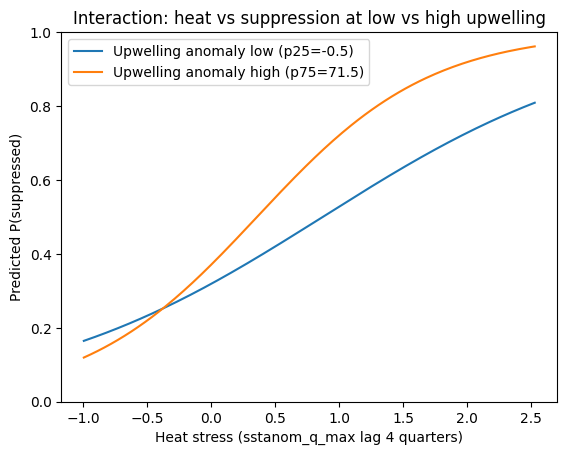

In [8]:
# plot everything
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# assumes df is already loaded + indexed to quarter-start like before
HEAT_LAG = 4

df = df.copy()
df["heat"] = df["sstanom_q_max"].shift(HEAT_LAG)
df["up"]   = df["uianom_q_mean_lag1"]
df["int"]  = df["heat"] * df["up"]

tmp = df[["suppressed","heat","up","int"]].dropna()
y = tmp["suppressed"].astype(int).values

X_raw = tmp[["heat","up","int"]].values
mu = X_raw.mean(axis=0)
sd = X_raw.std(axis=0)
X = (X_raw - mu) / sd

m = LogisticRegression(class_weight="balanced", max_iter=500)
m.fit(X, y)

# heat grid (raw units)
heat_grid = np.linspace(tmp["heat"].quantile(0.01), tmp["heat"].quantile(0.99), 200)

# upwelling low/high (raw units)
up_low  = tmp["up"].quantile(0.25)
up_high = tmp["up"].quantile(0.75)

def predict_prob(heat_vals, up_const):
    Xg_raw = np.column_stack([heat_vals, np.full_like(heat_vals, up_const), heat_vals * up_const])
    Xg = (Xg_raw - mu) / sd
    return m.predict_proba(Xg)[:, 1]

p_low  = predict_prob(heat_grid, up_low)
p_high = predict_prob(heat_grid, up_high)

plt.figure()
plt.plot(heat_grid, p_low,  label=f"Upwelling anomaly low (p25={up_low:.1f})")
plt.plot(heat_grid, p_high, label=f"Upwelling anomaly high (p75={up_high:.1f})")
plt.xlabel(f"Heat stress (sstanom_q_max lag {HEAT_LAG} quarters)")
plt.ylabel("Predicted P(suppressed)")
plt.title("Interaction: heat vs suppression at low vs high upwelling")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [3]:
#pooling 3 places together
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

REGIONS = ["norcal", "midcal", "socal"]
BASE = Path("../../1_DATA/processed")

def load_region(region):
    p1 = BASE / f"{region}_kelp_sst_ui_labeled.csv"
    p2 = BASE / region / f"{region}_kelp_sst_ui_labeled.csv"
    p = p1 if p1.exists() else p2
    if not p.exists():
        raise FileNotFoundError(f"Can't find labeled file for {region}: tried {p1} and {p2}")
    df = pd.read_csv(p, index_col=0, parse_dates=True).sort_index()
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df.index = df.index.to_period("Q").to_timestamp(how="start")
    df["region"] = region
    return df

dfs = [load_region(r) for r in REGIONS]
d = pd.concat(dfs, axis=0)

# sort cleanly: by region, then by time
d = d.sort_values(["region"]).sort_index()

# predictors
HEAT_LAG = 4
d["heat"] = d["sstanom_q_max"].shift(HEAT_LAG)
d["up"]   = d["uianom_q_mean_lag1"]
d["int"]  = d["heat"] * d["up"]

tmp = d[["region","suppressed","heat","up","int"]].dropna().copy()
tmp["suppressed"] = tmp["suppressed"].astype(int)

# standardize within region
for c in ["heat","up","int"]:
    tmp[c] = tmp.groupby("region")[c].transform(lambda x: (x - x.mean()) / x.std(ddof=0))

# region fixed effects
R = pd.get_dummies(tmp["region"], drop_first=True)
X = pd.concat([tmp[["heat","up","int"]], R], axis=1).values
y = tmp["suppressed"].values
regions_arr = tmp["region"].values

def boot_auc_by_region(X, y, regions, block_len=4, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    regions = np.asarray(regions)

    aucs = []
    for _ in range(B):
        idx_all = []
        for reg in np.unique(regions):
            idx = np.where(regions == reg)[0]
            n = len(idx)
            if n < block_len:
                continue
            starts = np.arange(0, n - block_len + 1)
            n_blocks = int(np.ceil(n / block_len))
            chosen = rng.choice(starts, size=n_blocks, replace=True)
            pick = np.concatenate([idx[s:s+block_len] for s in chosen])[:n]
            idx_all.append(pick)

        idxb = np.concatenate(idx_all)
        yb = y[idxb]
        if np.unique(yb).size < 2:
            continue

        m = LogisticRegression(class_weight="balanced", max_iter=500)
        m.fit(X[idxb], yb)
        p = m.predict_proba(X[idxb])[:, 1]
        aucs.append(roc_auc_score(yb, p))

    aucs = np.array(aucs)
    return aucs.mean(), np.quantile(aucs, [0.025, 0.975]), len(aucs)

auc_mean, auc_ci, n_ok = boot_auc_by_region(X, y, regions_arr, block_len=4, B=2000, seed=42)
print("POOLED model AUC:", auc_mean, "95% CI:", auc_ci, "| resamples:", n_ok)
print("Feature columns:", ["heat","up","int"] + list(R.columns))

POOLED model AUC: 0.7958318694667799 95% CI: [0.68794347 0.8895178 ] | resamples: 2000
Feature columns: ['heat', 'up', 'int', 'norcal', 'socal']


“Pooling regions (with region fixed effects) increases sample size and yields a robust climate–suppression signal (AUC ~0.80, block-bootstrap CI 0.69–0.89).”